<p> <h1># Transaction Anomaly Detection </h1>

<h1> Potential Fraud Detection using Isolation Forest </h1>
    Fraud Detection is a business problem. Since our transaction data does not contain fraud labels, we will use Unsupervised Learning → Anomaly Detection. For this, we will use Isolation Forest, an anomaly detection algorithm that identifies unusual transaction patterns and flags them as potentially suspicious. Anomaly does not necessarily mean confirmed fraud, so the results will be treated as suspicious transactions for further investigation.
</p>

In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [5]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv()

url = URL.create(
    drivername="mysql+pymysql",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=3306,
    database="banking_analytics"
)

engine = create_engine(url)

In [4]:
transactions = pd.read_sql(
    "SELECT * FROM transactions",
    engine
)

In [5]:
print(transactions.info())
print(transactions.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748514 entries, 0 to 748513
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   transaction_id             748514 non-null  int64         
 1   account_id                 748514 non-null  int64         
 2   transaction_date           748514 non-null  datetime64[ns]
 3   transaction_type           748514 non-null  object        
 4   transaction_mode           748514 non-null  object        
 5   amount                     748514 non-null  float64       
 6   balance_after_transaction  748514 non-null  float64       
 7   description                748514 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 45.7+ MB
None
(748514, 8)


<h1>4. Select Features for Anomaly Detection</h1>

In [6]:
# one hot encoding 
# convert into 0 / 1 formate
transaction_features = pd.get_dummies(
    transactions[[
        "amount",
        "balance_after_transaction",
        "transaction_mode"
    ]],
    columns=["transaction_mode"],
    dtype=int
)

transaction_features.head()

,amount,balance_after_transaction,transaction_mode_ATM,transaction_mode_Cash Deposit,transaction_mode_Credit Card,transaction_mode_Debit Card,transaction_mode_IMPS,transaction_mode_NEFT,transaction_mode_UPI
0,7281.0,3852719.0,0,0,0,0,0,0,1
1,45591.0,3807128.0,0,0,0,1,0,0,0
2,39620.0,3767508.0,0,0,1,0,0,0,0
3,46652.0,3720856.0,0,0,0,0,0,1,0
4,21607.0,3742463.0,0,0,0,0,0,1,0


<h1>Scale Transaction Features</h1>

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

transaction_features_scaled = scaler.fit_transform(transaction_features)

transaction_features_scaled.shape

(748514, 9)

<h1>7. Train Isolation Forest Model</h1>

In [8]:
from sklearn.ensemble import IsolationForest

isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

isolation_model.fit(transaction_features_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [9]:
anomaly_predictions = isolation_model.predict(transaction_features_scaled)

pd.Series(anomaly_predictions).value_counts()

 1    741030
-1      7484
Name: count, dtype: int64

In [10]:
transactions["anomaly"] = anomaly_predictions

transactions.head()

,transaction_id,account_id,transaction_date,transaction_type,transaction_mode,amount,balance_after_transaction,description,anomaly
0,1,1,2023-01-11,Debit,UPI,7281.0,3852719.0,Restaurant,1
1,2,1,2023-01-11,Debit,Debit Card,45591.0,3807128.0,Shopping,1
2,3,1,2023-01-11,Debit,Credit Card,39620.0,3767508.0,Online Purchase,1
3,4,1,2023-01-11,Debit,NEFT,46652.0,3720856.0,Rent,1
4,5,1,2024-08-22,Credit,NEFT,21607.0,3742463.0,Fund Transfer,1


In [11]:
suspicious_transactions = transactions[
    transactions["anomaly"] == -1
].copy()

suspicious_transactions.head(10)

,transaction_id,account_id,transaction_date,transaction_type,transaction_mode,amount,balance_after_transaction,description,anomaly
109,110,15,2020-07-06,Credit,IMPS,76095.0,44326095.0,Fund Transfer,-1
110,111,15,2020-07-17,Debit,Credit Card,17835.0,44308260.0,Restaurant,-1
111,112,15,2020-09-12,Credit,IMPS,62778.0,44371038.0,Fund Transfer,-1
112,113,15,2021-02-26,Debit,Credit Card,46098.0,44324940.0,Online Purchase,-1
461,462,62,2024-12-25,Credit,NEFT,97294.0,24634371.0,Fund Transfer,-1
493,494,68,2022-11-10,Credit,UPI,93136.0,43943136.0,Fund Transfer,-1
495,496,68,2024-12-11,Debit,ATM,38088.0,43892919.0,ATM Withdrawal,-1
497,498,68,2025-10-11,Credit,IMPS,97406.0,43976128.0,Fund Transfer,-1
883,884,119,2025-10-19,Credit,NEFT,77692.0,31285348.0,Salary,-1
935,936,126,2022-03-18,Credit,IMPS,15112.0,38422048.0,Salary,-1


<h1>10. Calculate Anomaly Score</h1>

In [12]:
anomaly_scores = isolation_model.decision_function(
    transaction_features_scaled
)

transactions["anomaly_score"] = anomaly_scores

In [13]:
suspicious_transactions = transactions[
    transactions["anomaly"] == -1
].copy()

suspicious_transactions = suspicious_transactions.sort_values(
    by="anomaly_score"
)

suspicious_transactions.head(10)

,transaction_id,account_id,transaction_date,transaction_type,transaction_mode,amount,balance_after_transaction,description,anomaly,anomaly_score
328201,328409,43838,2024-05-17,Credit,IMPS,99554.0,47099554.0,Salary,-1,-0.069108
546794,547158,73057,2025-02-28,Credit,IMPS,99887.0,49519467.0,Fund Transfer,-1,-0.069108
389996,390237,52114,2025-07-14,Credit,IMPS,99820.0,48449820.0,Interest Credit,-1,-0.069108
737750,738259,98563,2020-06-01,Credit,IMPS,98133.0,46298133.0,Interest Credit,-1,-0.069108
522372,522706,69800,2021-12-07,Credit,IMPS,99725.0,49167893.0,Fund Transfer,-1,-0.069108
522374,522708,69800,2022-11-27,Credit,IMPS,98311.0,49229526.0,Fund Transfer,-1,-0.069108
687055,687529,91778,2023-07-09,Credit,IMPS,99956.0,47856101.0,Salary,-1,-0.069108
165602,165711,22119,2024-05-06,Credit,IMPS,97710.0,48662358.0,Interest Credit,-1,-0.069108
83094,83152,11064,2020-01-21,Credit,IMPS,97803.0,49197803.0,Fund Transfer,-1,-0.069108
83892,83950,11170,2021-07-02,Credit,IMPS,98125.0,48260429.0,Interest Credit,-1,-0.069108


<h1>11. Analyze Suspicious Transactions</h1>

In [14]:
suspicious_transactions.groupby(
    ["transaction_type", "transaction_mode"]
).size().sort_values(ascending=False)

transaction_type  transaction_mode
Credit            IMPS                2432
                  Cash Deposit        1228
Debit             Credit Card          975
Credit            NEFT                 811
Debit             ATM                  723
                  Debit Card           518
Credit            UPI                  351
Debit             NEFT                 282
                  UPI                  164
dtype: int64

In [15]:
transactions.groupby("anomaly")["amount"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
anomaly,,,,
-1,7484,48215.605559,46007.5,99993.0
1,741030,27757.231703,21345.0,100000.0


<h1>12. Visualize Normal vs Suspicious Transactions</h1>

In [16]:
amount_summary = transactions.groupby("anomaly")["amount"].mean()

amount_summary.index = ["Suspicious", "Normal"]

amount_summary

Suspicious    48215.605559
Normal        27757.231703
Name: amount, dtype: float64

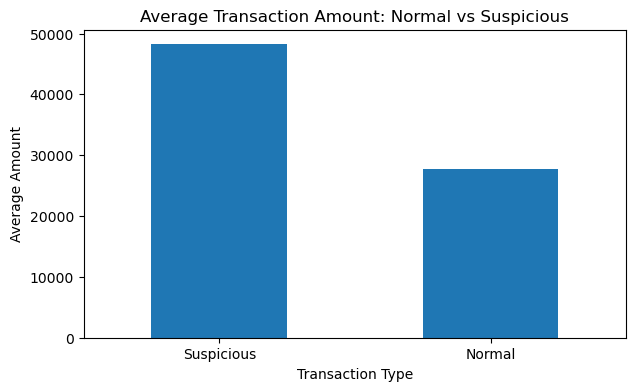

In [17]:
import matplotlib.pyplot as plt
amount_summary.plot(
    kind="bar",
    figsize=(7, 4),
    title="Average Transaction Amount: Normal vs Suspicious"
)

plt.xlabel("Transaction Type")
plt.ylabel("Average Amount")
plt.xticks(rotation=0)
plt.show()

<h1>13. Conclusion</h1>

<p>## 13. Conclusion

Isolation Forest was used to identify potentially suspicious transactions because the dataset did not contain fraud labels. The model flagged 7,484 out of 748,514 transactions as anomalies. Suspicious transactions had a higher average transaction amount (₹48,215.61) compared to normal transactions (₹27,757.23). These anomalies should be treated as potentially suspicious transactions rather than confirmed fraud and can be further investigated by the bank.</p>

<H1>14. Create Transaction Prediction Function</H1>

In [18]:
def detect_transaction_anomaly(amount, balance_after_transaction, transaction_mode):
    
    new_transaction = pd.DataFrame([{
        "amount": amount,
        "balance_after_transaction": balance_after_transaction,
        "transaction_mode": transaction_mode
    }])
    
    # One-hot encoding
    new_transaction = pd.get_dummies(
        new_transaction,
        columns=["transaction_mode"],
        dtype=int
    )
    
    # Match training columns
    new_transaction = new_transaction.reindex(
        columns=transaction_features.columns,
        fill_value=0
    )
    
    # Scale features
    new_transaction_scaled = scaler.transform(new_transaction)
    
    # Prediction
    prediction = isolation_model.predict(new_transaction_scaled)
    
    if prediction[0] == 1:
        return "Normal"
    else:
        return "Potentially Suspicious"

In [19]:
detect_transaction_anomaly(
    amount=5000,
    balance_after_transaction=200000000,
    transaction_mode="UPI"
)

'Potentially Suspicious'

In [20]:
detect_transaction_anomaly(
    amount=5000,
    balance_after_transaction=1,
    transaction_mode="UPI"
)

'Normal'

In [21]:
detect_transaction_anomaly(
    amount=99000,
    balance_after_transaction=500000,
    transaction_mode="IMPS"
)

'Normal'

In [22]:
test_row = suspicious_transactions.iloc[0]

detect_transaction_anomaly(
    amount=test_row["amount"],
    balance_after_transaction=test_row["balance_after_transaction"],
    transaction_mode=test_row["transaction_mode"]
)

'Potentially Suspicious'

In [23]:
import joblib

joblib.dump(isolation_model, "../Models/transaction_anomaly_model.pkl")
joblib.dump(scaler, "../Models/transaction_anomaly_scaler.pkl")

['../Models/transaction_anomaly_scaler.pkl']